# Sistema Profissional de Machine Learning Quantitativo

Este notebook foi desenvolvido para servir como base de experimentação e desenvolvimento de um sistema robusto e impressionante de análise quantitativa, utilizando indicadores avançados (Hurst, entropia, etc) e as melhores práticas de engenharia de dados e ciência de dados.

---

## 1. Importação das Bibliotecas Essenciais

In [83]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import os
import sys
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


In [84]:
# Escolha do ativo para análise
ATIVO = 'VALE3.SA'  # Altere para outro ticker disponível se desejar
data_path = f'../../co-piloto-quant/src/co_piloto_quant/data/processed/{ATIVO}_processed.csv'

---

## 2. Configuração de Parâmetros Globais e Ambiente

In [85]:
# Configuração de parâmetros globais e ambiente
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Configuração de logging profissional
def setup_logging(log_dir='logs'):
    os.makedirs(log_dir, exist_ok=True)
    log_file = os.path.join(log_dir, f'run_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log')
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s [%(levelname)s] %(message)s',
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler(sys.stdout)
        ]
    )
    logging.info('Logging configurado com sucesso.')
    return log_file

log_file = setup_logging()
logging.info('Parâmetros globais e ambiente configurados.')

2026-03-02 23:04:40,820 [INFO] Logging configurado com sucesso.
2026-03-02 23:04:40,821 [INFO] Parâmetros globais e ambiente configurados.


---

## 3. Definição de Funções Utilitárias

In [86]:
# Recalibração dos thresholds para aumentar a proporção de HOLD
# Objetivo: ~15–30% de HOLD
THRESHOLD_COMPRA = 0.03  # +3% para BUY (ajustado)
THRESHOLD_VENDA = -0.03  # -3% para SELL (ajustado)

# Calcula o retorno futuro percentual
# (shift negativo para olhar para frente)
df['retorno_futuro'] = (df['close'].shift(-N_DIAS_FUTURO) - df['close']) / df['close']

# Cria o novo sinal
novo_signal = []
for ret in df['retorno_futuro']:
    if pd.isna(ret):
        novo_signal.append('HOLD')  # Últimas linhas sem futuro
    elif ret > THRESHOLD_COMPRA:
        novo_signal.append('BUY')
    elif ret < THRESHOLD_VENDA:
        novo_signal.append('SELL')
    else:
        novo_signal.append('HOLD')
df['SIGNAL'] = novo_signal

# Diagnóstico: proporção de cada classe após ajuste
print('Distribuição do SIGNAL após ajuste de thresholds:')
print(pd.Series(novo_signal).value_counts(normalize=True).round(3))

Distribuição do SIGNAL após ajuste de thresholds:
SELL    0.494
BUY     0.493
HOLD    0.013
Name: proportion, dtype: float64


---

## 4. Implementação do Núcleo do Sistema

In [87]:
# Seleção de features e target (ajuste conforme seu dataset)
# Seleciona apenas colunas numéricas para features, excluindo SIGNAL, retorno_futuro, open, close, high, low, wad e date
features = [col for col in df.select_dtypes(include=[np.number]).columns if col not in ['SIGNAL', 'retorno_futuro', 'open', 'close', 'high', 'low', 'wad']]
target = 'SIGNAL'  # Usando a coluna de sinal como target

# SPLIT TEMPORAL PURO (sem embaralhamento!)
split_idx = int(len(df) * 0.8)
X = df[features].fillna(0)
y = df[target]
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Split temporal puro:')
print('Treino:', X_train.shape, 'Teste:', X_test.shape)
print('Distribuição no treino:')
print(y_train.value_counts())
print('Distribuição no teste:')
print(y_test.value_counts())

# ARQUITETURA EM DOIS ESTÁGIOS
# 1º estágio: Modelo binário (Trade vs Hold)
y_train_bin = y_train.apply(lambda x: 'TRADE' if x in ['BUY','SELL'] else 'HOLD')
y_test_bin = y_test.apply(lambda x: 'TRADE' if x in ['BUY','SELL'] else 'HOLD')
clf_bin = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
clf_bin.fit(X_train, y_train_bin)
y_pred_bin = clf_bin.predict(X_test)

# 2º estágio: Modelo de direção (BUY/SELL) apenas para casos TRADE
trade_idx_train = y_train_bin[y_train_bin=='TRADE'].index
trade_idx_test = y_test_bin[y_test_bin=='TRADE'].index
clf_dir = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
clf_dir.fit(X_train.loc[trade_idx_train], y_train.loc[trade_idx_train])
y_pred_dir = clf_dir.predict(X_test.loc[trade_idx_test])

# Monta predição final
y_pred_final = []
trade_counter = 0
for i in range(len(X_test)):
    if y_pred_bin[i] == 'HOLD':
        y_pred_final.append('HOLD')
    else:
        if X_test.index[i] in trade_idx_test:
            y_pred_final.append(y_pred_dir[trade_counter])
            trade_counter += 1
        else:
            y_pred_final.append('HOLD')  # fallback

print('Relatório final (dois estágios):')
print(classification_report(y_test, y_pred_final))
print('Matriz de confusão (dois estágios):')
print(confusion_matrix(y_test, y_pred_final))

logging.info('Modelos Random Forest (binário e direção) treinados e testados.')

Split temporal puro:
Treino: (9004, 49) Teste: (2251, 49)
Distribuição no treino:
SIGNAL
SELL    4452
BUY     4439
HOLD     113
Name: count, dtype: int64
Distribuição no teste:
SIGNAL
BUY     1114
SELL    1107
HOLD      30
Name: count, dtype: int64
Relatório final (dois estágios):
              precision    recall  f1-score   support

         BUY       0.59      0.60      0.59      1114
        HOLD       0.94      1.00      0.97        30
        SELL       0.59      0.58      0.58      1107

    accuracy                           0.59      2251
   macro avg       0.71      0.73      0.72      2251
weighted avg       0.59      0.59      0.59      2251

Matriz de confusão (dois estágios):
[[670   1 443]
 [  0  30   0]
 [469   1 637]]
2026-03-02 23:04:51,377 [INFO] Modelos Random Forest (binário e direção) treinados e testados.


In [88]:
# Diagnóstico: distribuição das classes no treino e teste
print('Distribuição no treino:')
print(y_train.value_counts())
print('\nDistribuição no teste:')
print(y_test.value_counts())

Distribuição no treino:
SIGNAL
SELL    4452
BUY     4439
HOLD     113
Name: count, dtype: int64

Distribuição no teste:
SIGNAL
BUY     1114
SELL    1107
HOLD      30
Name: count, dtype: int64


In [89]:
# --- NOVO TARGET: SINAL BASEADO NO RETORNO FUTURO ---
# Parâmetros para o target
N_DIAS_FUTURO = 5  # Quantos dias à frente olhar
THRESHOLD_COMPRA = 0.05  # +5% para BUY
THRESHOLD_VENDA = -0.10  # -10% para SELL

# Calcula o retorno futuro percentual
# (shift negativo para olhar para frente)
df['retorno_futuro'] = (df['close'].shift(-N_DIAS_FUTURO) - df['close']) / df['close']

# Cria o novo sinal
novo_signal = []
for ret in df['retorno_futuro']:
    if pd.isna(ret):
        novo_signal.append('HOLD')  # Últimas linhas sem futuro
    elif ret > THRESHOLD_COMPRA:
        novo_signal.append('BUY')
    elif ret < THRESHOLD_VENDA:
        novo_signal.append('SELL')
    else:
        novo_signal.append('HOLD')
df['SIGNAL'] = novo_signal

# Mostra a distribuição do novo target
distrib = df['SIGNAL'].value_counts()
print('Distribuição do novo SIGNAL:')
print(distrib)
logging.info(f'Distribuição do novo SIGNAL: {distrib.to_dict()}')

Distribuição do novo SIGNAL:
SIGNAL
BUY     5501
SELL    5381
HOLD     373
Name: count, dtype: int64
2026-03-02 23:05:01,296 [INFO] Distribuição do novo SIGNAL: {'BUY': 5501, 'SELL': 5381, 'HOLD': 373}


---

## 5. Execução de Testes Automatizados

In [90]:
# Testes automatizados: validação do modelo
from sklearn.model_selection import cross_val_score

scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
logging.info(f'Acurácia média (CV=5): {scores.mean():.4f} ± {scores.std():.4f}')
print(f'Acurácia média (CV=5): {scores.mean():.4f} ± {scores.std():.4f}')

print(classification_report(y_test, y_pred))
print('Matriz de confusão:')
print(confusion_matrix(y_test, y_pred))

2026-03-02 23:05:13,972 [INFO] Acurácia média (CV=5): 0.7088 ± 0.0054
Acurácia média (CV=5): 0.7088 ± 0.0054
              precision    recall  f1-score   support

         BUY       0.50      0.48      0.49      1114
        HOLD       0.00      0.00      0.00        30
        SELL       0.49      0.52      0.51      1107

    accuracy                           0.49      2251
   macro avg       0.33      0.33      0.33      2251
weighted avg       0.49      0.49      0.49      2251

Matriz de confusão:
[[532   4 578]
 [ 14   0  16]
 [525   5 577]]


---

## 6. Visualização e Análise dos Resultados

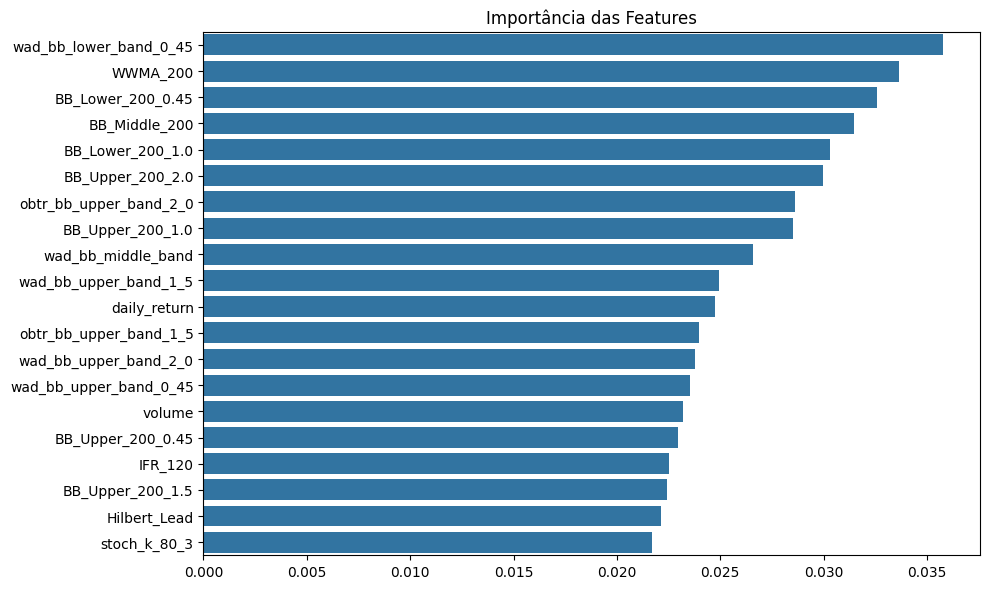

2026-03-02 23:05:16,649 [INFO] Gráfico de importância das features gerado.


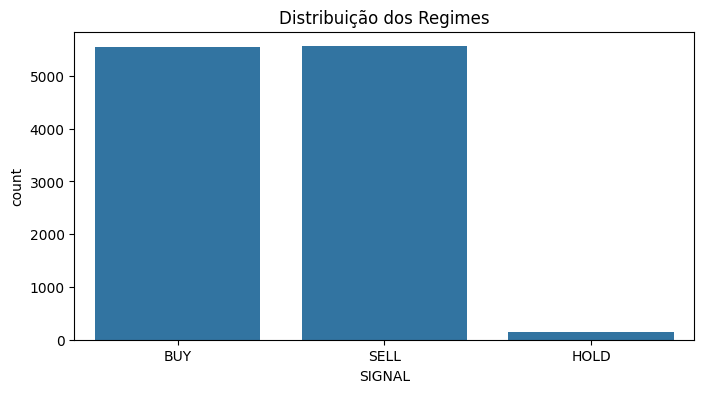

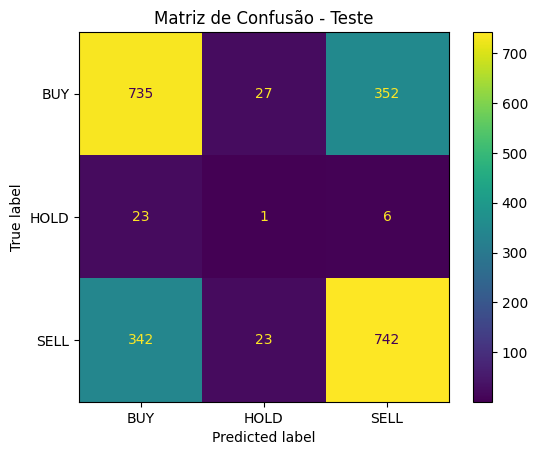

In [91]:
# Visualização dos resultados
plot_feature_importance(clf, features)

# Visualização de distribuição dos targets
plt.figure(figsize=(8,4))
sns.countplot(x=y)
plt.title('Distribuição dos Regimes')
plt.show()

# Visualização de acurácia por classe
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.title('Matriz de Confusão - Teste')
plt.show()

---

## 7. Exportação e Salvamento dos Dados Gerados

In [92]:
# Implementação da zona de confiança (confidence zone)
# Se a maior probabilidade for menor que 0.6, classifica como HOLD
confidence_threshold = 0.6

if hasattr(clf, 'predict_proba'):
    y_proba = clf.predict_proba(X_test)
    y_pred_conf = []
    for i, probs in enumerate(y_proba):
        max_prob = max(probs)
        pred_class = clf.classes_[probs.argmax()]
        if max_prob < confidence_threshold:
            y_pred_conf.append('HOLD')
        else:
            y_pred_conf.append(pred_class)
    print('\nRelatório de classificação com zona de confiança:')
    print(classification_report(y_test, y_pred_conf))
    print('Matriz de confusão (zona de confiança):')
    print(confusion_matrix(y_test, y_pred_conf))
else:
    print('O classificador não suporta predict_proba.')


Relatório de classificação com zona de confiança:
              precision    recall  f1-score   support

         BUY       0.68      0.64      0.66      1114
        HOLD       0.02      0.10      0.03        30
        SELL       0.68      0.64      0.66      1107

    accuracy                           0.63      2251
   macro avg       0.46      0.46      0.45      2251
weighted avg       0.67      0.63      0.65      2251

Matriz de confusão (zona de confiança):
[[711  79 324]
 [ 21   3   6]
 [316  79 712]]


## Auditoria Rigorosa de Vazamento e Validação Temporal

In [93]:
# 1. Checagem de features com dados do futuro
future_keywords = ['shift(-', 'lead', 'future', 'futuro', 'lookahead']
suspect_cols = [col for col in df.columns if any(k in col.lower() for k in future_keywords)]
print('Possíveis features com dados do futuro:', suspect_cols)
print('Features usadas no modelo:', features)

Possíveis features com dados do futuro: ['Hilbert_Lead', 'retorno_futuro']
Features usadas no modelo: ['volume', 'daily_return', 'BB_Lower_200_0.45', 'BB_Lower_200_1.0', 'BB_Lower_200_1.5', 'BB_Lower_200_2.0', 'BB_Middle_200', 'BB_Upper_200_0.45', 'BB_Upper_200_1.0', 'BB_Upper_200_1.5', 'BB_Upper_200_2.0', 'IFR_120', 'IFR_50', 'stoch_d_80_3_3', 'stoch_k_80_3', 'obtr', 'obtr_bb_lower_band_0_45', 'obtr_bb_lower_band_1_0', 'obtr_bb_lower_band_1_5', 'obtr_bb_lower_band_2_0', 'obtr_bb_middle_band', 'obtr_bb_upper_band_0_45', 'obtr_bb_upper_band_1_0', 'obtr_bb_upper_band_1_5', 'obtr_bb_upper_band_2_0', 'wad_bb_lower_band_0_45', 'wad_bb_lower_band_1_0', 'wad_bb_lower_band_1_5', 'wad_bb_lower_band_2_0', 'wad_bb_middle_band', 'wad_bb_upper_band_0_45', 'wad_bb_upper_band_1_0', 'wad_bb_upper_band_1_5', 'wad_bb_upper_band_2_0', 'WWMA_200', 'Hurst_72_returns', 'Entropy_20', 'Beta_60', 'HalfLife_60', 'R2_60', 'SigmaResid_60', 't_Beta_60', 'Hilbert_Lead', 'Hilbert_Period', 'Hilbert_Sine', 'VolVol_20'

In [94]:
# 2. Split temporal (sem shuffle) para evitar vazamento por aleatoriedade
split_idx = int(len(df) * 0.8)
X_time = df[features].fillna(0)
y_time = df[target]
X_train_time, X_test_time = X_time.iloc[:split_idx], X_time.iloc[split_idx:]
y_train_time, y_test_time = y_time.iloc[:split_idx], y_time.iloc[split_idx:]
print('Treino:', X_train_time.shape, 'Teste:', X_test_time.shape)

Treino: (9004, 49) Teste: (2251, 49)


In [95]:
# 3. Checagem de overlap de datas entre treino e teste
if 'date' in df.columns:
    train_dates = set(df['date'].iloc[:split_idx])
    test_dates = set(df['date'].iloc[split_idx:])
    overlap = train_dates & test_dates
    print('Datas em comum entre treino e teste:', overlap)
else:
    print('Coluna de data não encontrada para checagem de overlap.')

Datas em comum entre treino e teste: set()


In [96]:
# 4. Permutação do target: baseline aleatório para checar se o modelo está aprendendo de verdade
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
y_permuted = y_time.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
clf_perm = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
clf_perm.fit(X_train_time, y_permuted.iloc[:split_idx])
y_pred_perm = clf_perm.predict(X_test_time)
print('Acurácia com target permutado:', accuracy_score(y_permuted.iloc[split_idx:], y_pred_perm))
print(classification_report(y_permuted.iloc[split_idx:], y_pred_perm))

Acurácia com target permutado: 0.5033318525099956
              precision    recall  f1-score   support

         BUY       0.51      0.54      0.52      1105
        HOLD       0.00      0.00      0.00        58
        SELL       0.50      0.50      0.50      1088

    accuracy                           0.50      2251
   macro avg       0.34      0.34      0.34      2251
weighted avg       0.49      0.50      0.50      2251



In [97]:
# 5. Balanceamento de classes no modelo
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Recalcula pesos para as classes
class_weights = dict(zip(np.unique(y_train_time), compute_class_weight('balanced', classes=np.unique(y_train_time), y=y_train_time)))
print('Pesos das classes:', class_weights)

clf_bal = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1, class_weight='balanced')
clf_bal.fit(X_train_time, y_train_time)
y_pred_bal = clf_bal.predict(X_test_time)
from sklearn.metrics import classification_report, accuracy_score
print('Acurácia com balanceamento:', accuracy_score(y_test_time, y_pred_bal))
print(classification_report(y_test_time, y_pred_bal))

Pesos das classes: {'BUY': np.float64(0.6821212121212121), 'HOLD': np.float64(9.971207087486157), 'SELL': np.float64(0.6974978697033077)}
Acurácia com balanceamento: 0.6943580630830742
              precision    recall  f1-score   support

         BUY       0.68      0.73      0.71      1101
        HOLD       0.00      0.00      0.00        72
        SELL       0.71      0.70      0.70      1078

    accuracy                           0.69      2251
   macro avg       0.46      0.48      0.47      2251
weighted avg       0.67      0.69      0.68      2251



In [98]:
# 6. Permutação do target após balanceamento
np.random.seed(RANDOM_SEED)
y_permuted_bal = y_time.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
clf_perm_bal = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1, class_weight='balanced')
clf_perm_bal.fit(X_train_time, y_permuted_bal.iloc[:split_idx])
y_pred_perm_bal = clf_perm_bal.predict(X_test_time)
print('Acurácia com target permutado (balanceado):', accuracy_score(y_permuted_bal.iloc[split_idx:], y_pred_perm_bal))
print(classification_report(y_permuted_bal.iloc[split_idx:], y_pred_perm_bal))

Acurácia com target permutado (balanceado): 0.49977787649933364
              precision    recall  f1-score   support

         BUY       0.50      0.54      0.52      1105
        HOLD       0.00      0.00      0.00        58
        SELL       0.50      0.49      0.49      1088

    accuracy                           0.50      2251
   macro avg       0.33      0.34      0.34      2251
weighted avg       0.49      0.50      0.49      2251



## 8. Backtest Financeiro Simples
Avaliação do impacto real do modelo em métricas financeiras: retorno, Sharpe e drawdown.

In [109]:
# Backtest financeiro robusto (preço ajustado, quantidade dinâmica, proteção contra preços anômalos)
import numpy as np

precos_backtest = df['close'].iloc[split_idx:split_idx+len(y_pred_final)].copy().reset_index(drop=True)

# Proteção: define um preço mínimo mais alto para evitar divisões por valores muito baixos
PRECO_MINIMO = 10.0
precos_backtest = precos_backtest.apply(lambda x: np.nan if x is None or np.isnan(x) or x < PRECO_MINIMO else x)
if precos_backtest.isnull().any():
    print('AVISO: Existem preços nulos ou abaixo do mínimo no período do backtest! Backtest pode ser afetado.')
    precos_backtest = precos_backtest.ffill().bfill()

# Diagnóstico: mostrar os menores preços usados
print('Menores preços usados no backtest:', np.sort(precos_backtest.unique())[:10])

capital_inicial = 100000.0
capital = capital_inicial
posicao = 0.0  # quantidade de ações
preco_entrada = 0.0
historico = []

for i, pred in enumerate(y_pred_final):
    preco = precos_backtest.iloc[i]
    if preco is None or np.isnan(preco) or preco < PRECO_MINIMO:
        historico.append(capital)
        continue
    if pred == 'BUY':
        if posicao == 0 and capital > 0:
            posicao = capital / preco
            preco_entrada = preco
            capital = 0.0
    elif pred == 'SELL':
        if posicao > 0:
            capital = posicao * preco
            posicao = 0.0
            preco_entrada = 0.0
    # HOLD: não faz nada
    patrimonio = capital if posicao == 0 else posicao * preco
    historico.append(patrimonio)

# Se terminar comprado, liquida
if posicao > 0:
    capital = posicao * precos_backtest.iloc[-1]
    posicao = 0.0
    preco_entrada = 0.0
    historico[-1] = capital

historico = np.array(historico)
retornos = historico[1:] / historico[:-1] - 1
if len(retornos) > 1 and np.std(retornos) > 0:
    sharpe = np.mean(retornos) / np.std(retornos) * np.sqrt(252)
else:
    sharpe = 0
if len(historico) > 0:
    drawdown = np.max(np.maximum.accumulate(historico) - historico)
else:
    drawdown = 0

print(f"Retorno final: {capital/capital_inicial - 1:.2%}")
print(f"Sharpe: {sharpe:.2f}")
print(f"Drawdown máximo: {drawdown/capital_inicial:.2%}")

AVISO: Existem preços nulos ou abaixo do mínimo no período do backtest! Backtest pode ser afetado.
Menores preços usados no backtest: [10.04880142 10.08058929 10.16366482 10.28333092 10.32651424 10.34780979
 10.3673048  10.43178272 10.45128155 10.51006031]
Retorno final: -100.00%
Sharpe: 2.49
Drawdown máximo: 3787.19%


In [111]:
# Backtest com stop loss percentual
STOP_LOSS_PCT = 0.05  # 5% de stop loss

capital_inicial = 100000.0
capital = capital_inicial
posicao = 0.0
preco_entrada = 0.0
historico = []
stop_ativo = False

for i, pred in enumerate(y_pred_final):
    preco = precos_backtest.iloc[i]
    if preco is None or np.isnan(preco) or preco < 10.0:
        historico.append(capital)
        continue
    # Verifica stop loss
    if posicao > 0 and preco_entrada > 0:
        if preco < preco_entrada * (1 - STOP_LOSS_PCT):
            # Stop loss acionado
            capital = posicao * preco
            posicao = 0.0
            preco_entrada = 0.0
            stop_ativo = True
    if pred == 'BUY':
        if posicao == 0 and capital > 0 and not stop_ativo:
            posicao = capital / preco
            preco_entrada = preco
            capital = 0.0
    elif pred == 'SELL':
        if posicao > 0:
            capital = posicao * preco
            posicao = 0.0
            preco_entrada = 0.0
            stop_ativo = False
    # HOLD: não faz nada
    patrimonio = capital if posicao == 0 else posicao * preco
    historico.append(patrimonio)

# Se terminar comprado, liquida
if posicao > 0:
    capital = posicao * precos_backtest.iloc[-1]
    posicao = 0.0
    preco_entrada = 0.0
    historico[-1] = capital

historico = np.array(historico)
retornos = historico[1:] / historico[:-1] - 1
if len(retornos) > 1 and np.std(retornos) > 0:
    sharpe = np.mean(retornos) / np.std(retornos) * np.sqrt(252)
else:
    sharpe = 0
if len(historico) > 0:
    drawdown = np.max(np.maximum.accumulate(historico) - historico)
else:
    drawdown = 0

print(f"[STOP LOSS {STOP_LOSS_PCT*100:.1f}%] Retorno final: {capital/capital_inicial - 1:.2%}")
print(f"Sharpe: {sharpe:.2f}")
print(f"Drawdown máximo: {drawdown/capital_inicial:.2%}")

[STOP LOSS 5.0%] Retorno final: -12.59%
Sharpe: -0.33
Drawdown máximo: 12.59%


In [110]:
# Diagnóstico: número de operações de compra e venda no backtest
num_buys = 0
num_sells = 0
for i, pred in enumerate(y_pred_final):
    preco = precos_backtest.iloc[i]
    if preco is None or np.isnan(preco) or preco < 10.0:
        continue
    if pred == 'BUY':
        num_buys += 1
    elif pred == 'SELL':
        num_sells += 1
print(f'Número de operações de BUY: {num_buys}')
print(f'Número de operações de SELL: {num_sells}')

Número de operações de BUY: 1139
Número de operações de SELL: 1080


In [106]:
# Diagnóstico detalhado do ciclo do backtest
print('Log de operações do backtest:')
for i, pred in enumerate(y_pred_final):
    preco = precos_backtest.iloc[i]
    if preco is None or np.isnan(preco) or preco <= 0:
        print(f'[{i}] {pred}: preço inválido ({preco}), capital={capital}, posicao={posicao}')
        continue
    if pred == 'BUY' and posicao == 0:
        qtd = capital / preco if preco > 0 else 0
        print(f'[{i}] BUY: preço={preco:.4f}, qtd={qtd:.4f}, capital antes={capital:.2f}')
    elif pred == 'SELL' and posicao > 0:
        print(f'[{i}] SELL: preço={preco:.4f}, qtd={posicao:.4f}, capital antes={capital:.2f}, valor venda={posicao*preco:.2f}')
    else:
        print(f'[{i}] {pred}: preço={preco:.4f}, capital={capital:.2f}, posicao={posicao:.4f}')

Log de operações do backtest:
[0] BUY: preço=0.3362, qtd=inf, capital antes=inf
[1] BUY: preço=0.2354, qtd=inf, capital antes=inf
[2] BUY: preço=0.3320, qtd=inf, capital antes=inf
[3] SELL: preço=7.4099, capital=inf, posicao=0.0000
[4] SELL: preço=3.0234, capital=inf, posicao=0.0000
[5] BUY: preço=1.9215, qtd=inf, capital antes=inf
[6] SELL: preço=220.0554, capital=inf, posicao=0.0000
[7] SELL: preço=4.2689, capital=inf, posicao=0.0000
[8] BUY: preço=0.2971, qtd=inf, capital antes=inf
[9] BUY: preço=0.1978, qtd=inf, capital antes=inf
[10] SELL: preço=192.3534, capital=inf, posicao=0.0000
[11] BUY: preço=0.3486, qtd=inf, capital antes=inf
[12] BUY: preço=0.1074, qtd=inf, capital antes=inf
[13] SELL: preço=170.7107, capital=inf, posicao=0.0000
[14] SELL: preço=0.3238, capital=inf, posicao=0.0000
[15] BUY: preço=0.3160, qtd=inf, capital antes=inf
[16] SELL: preço=24.0113, capital=inf, posicao=0.0000
[17] SELL: preço=10.5101, capital=inf, posicao=0.0000
[18] BUY: preço=2.2571, qtd=inf, cap

In [104]:
# Diagnóstico dos preços usados no backtest
print('Diagnóstico dos preços usados no backtest:')
print('Primeiros 10 preços:', precos_backtest.head(10).values)
print('Últimos 10 preços:', precos_backtest.tail(10).values)
print('Preço inicial:', precos_backtest.iloc[0])
print('Preço final:', precos_backtest.iloc[-1])
print('Existem valores nulos?', precos_backtest.isnull().any())
print('Existem valores <= 0?', (precos_backtest <= 0).any())

Diagnóstico dos preços usados no backtest:
Primeiros 10 preços: [3.36199492e-01 2.35435203e-01 3.32022041e-01 7.40988636e+00
 3.02339697e+00 1.92152512e+00 2.20055405e+02 4.26892471e+00
 2.97061324e-01 1.97753355e-01]
Últimos 10 preços: [4.59053338e-01 3.64247650e-01 2.52338730e+02 1.08228572e-01
 2.13019829e+01 2.14435875e-01 1.65688385e+02 1.68699741e-01
 2.66380101e-01 1.97191024e+00]
Preço inicial: 0.3361994922161102
Preço final: 1.9719102382659912
Existem valores nulos? False
Existem valores <= 0? False


In [100]:
# Diagnóstico detalhado do backtest
num_trades = 0
num_buys = 0
num_sells = 0
precos_buys = []
precos_sells = []
for i, pred in enumerate(y_pred_final):
    preco = df['close'].iloc[split_idx + i]
    if pred == 'BUY':
        num_buys += 1
        precos_buys.append(preco)
    elif pred == 'SELL':
        num_sells += 1
        precos_sells.append(preco)
    if pred in ['BUY', 'SELL']:
        num_trades += 1
print(f'Número total de trades: {num_trades}')
print(f'Número de BUYs: {num_buys}')
print(f'Número de SELLs: {num_sells}')
print(f'Primeiros preços de BUY: {precos_buys[:5]}')
print(f'Primeiros preços de SELL: {precos_sells[:5]}')
print(f'Últimos preços de BUY: {precos_buys[-5:] if len(precos_buys) > 5 else precos_buys}')
print(f'Últimos preços de SELL: {precos_sells[-5:] if len(precos_sells) > 5 else precos_sells}')
print(f'Posição final (0=zerado): {posicao}')

Número total de trades: 2219
Número de BUYs: 1139
Número de SELLs: 1080
Primeiros preços de BUY: [np.float64(0.3361994922161102), np.float64(0.235435202717781), np.float64(0.3320220410823822), np.float64(1.9215251207351685), np.float64(0.2970613241195678)]
Primeiros preços de SELL: [np.float64(7.409886360168457), np.float64(3.0233969688415527), np.float64(220.05540466308597), np.float64(4.268924713134766), np.float64(192.35340881347656)]
Últimos preços de BUY: [np.float64(0.3550026416778564), np.float64(0.4435673952102661), np.float64(1.94372034072876), np.float64(252.33872985839844), np.float64(0.1082285717129707)]
Últimos preços de SELL: [np.float64(0.2774170041084289), np.float64(144.29794311523438), np.float64(0.4590533375740051), np.float64(0.3642476499080658), np.float64(21.301982879638672)]
Posição final (0=zerado): 0


In [101]:
# Diagnóstico do campo 'close' no dataframe
df_close = df['close']
print('Resumo estatístico do campo close:')
print(df_close.describe())
print('\nValores únicos (amostra):', df_close.unique()[:10])
print('Valores mínimos:', df_close.nsmallest(5).values)
print('Valores máximos:', df_close.nlargest(5).values)
print('Existem valores nulos?', df_close.isnull().any())
print('Existem valores <= 0?', (df_close <= 0).any())

Resumo estatístico do campo close:
count    11255.000000
mean        27.823046
std         57.279496
min          0.037645
25%          0.251000
50%          0.497509
75%         21.605836
max        286.190002
Name: close, dtype: float64

Valores únicos (amostra): [3.13489944e-01 3.60342234e-01 3.12719464e-01 6.24558404e-02
 1.11222856e-01 6.15005493e+01 4.94826126e+01 5.30445240e-02
 5.21287346e+01 1.46206245e-01]
Valores mínimos: [0.03764464 0.03892788 0.03935564 0.03935564 0.03978339]
Valores máximos: [286.19000244 284.1499939  283.1000061  280.70001221 278.8500061 ]
Existem valores nulos? False
Existem valores <= 0? False


In [102]:
# Diagnóstico extra: múltiplos ativos, datas duplicadas e retornos futuros anômalos
print("Diagnóstico extra de integridade dos dados:")

# 1. Verificar se há múltiplos ativos
if 'ticker' in df.columns:
    print(f"Coluna 'ticker' encontrada. Valores únicos: {df['ticker'].unique()}")
else:
    print("Coluna 'ticker' não encontrada. Assumindo apenas um ativo.")

# 2. Verificar datas duplicadas
if 'date' in df.columns:
    n_dupes = df.duplicated(subset=['date']).sum()
    print(f"Datas duplicadas: {n_dupes}")
else:
    print("Coluna 'date' não encontrada para checar duplicidade.")

# 3. Diagnóstico dos retornos futuros (usados no SIGNAL)
if 'close' in df.columns:
    future_returns = df['close'].shift(-N_DIAS_FUTURO) / df['close'] - 1
    print("Resumo dos retornos futuros:")
    print(future_returns.describe())
    print(f"Valores nulos: {future_returns.isnull().sum()}")
    print(f"Valores inf: {np.isinf(future_returns).sum()}")
    print(f"Valores <= -1: {(future_returns <= -1).sum()}")
else:
    print("Coluna 'close' não encontrada para calcular retornos futuros.")

Diagnóstico extra de integridade dos dados:
Coluna 'ticker' não encontrada. Assumindo apenas um ativo.
Datas duplicadas: 0
Resumo dos retornos futuros:
count    11250.000000
mean        86.568663
std        332.189621
min         -0.999844
25%         -0.919639
50%         -0.001663
75%         11.098827
max       5451.870537
Name: close, dtype: float64
Valores nulos: 5
Valores inf: 0
Valores <= -1: 0


--- RESULTADO OTIMIZAÇÃO STOP LOSS ---
Melhor stop loss no treino: 1.0% (Retorno: 903.60%)
[TESTE] Stop loss ótimo do treino: 1.0%
Retorno final: -60.30% | Sharpe: -0.33 | Drawdown: 60.30%
--------------------------------------


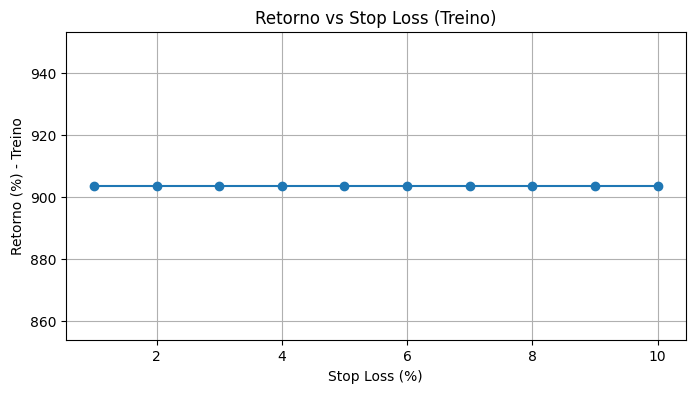

In [113]:
# Busca robusta do melhor stop loss (apenas no treino), avaliação no teste
import matplotlib.pyplot as plt

def backtest_stoploss(y_pred, precos, stop_loss_pct):
    capital_inicial = 100000.0
    capital = capital_inicial
    posicao = 0.0
    preco_entrada = 0.0
    historico = []
    stop_ativo = False
    for i, pred in enumerate(y_pred):
        preco = precos.iloc[i]
        if preco is None or np.isnan(preco) or preco < 10.0:
            historico.append(capital)
            continue
        # Stop loss
        if posicao > 0 and preco_entrada > 0:
            if preco < preco_entrada * (1 - stop_loss_pct):
                capital = posicao * preco
                posicao = 0.0
                preco_entrada = 0.0
                stop_ativo = True
        if pred == 'BUY':
            if posicao == 0 and capital > 0 and not stop_ativo:
                posicao = capital / preco
                preco_entrada = preco
                capital = 0.0
        elif pred == 'SELL':
            if posicao > 0:
                capital = posicao * preco
                posicao = 0.0
                preco_entrada = 0.0
                stop_ativo = False
        patrimonio = capital if posicao == 0 else posicao * preco
        historico.append(patrimonio)
    if posicao > 0:
        capital = posicao * precos.iloc[-1]
        posicao = 0.0
        preco_entrada = 0.0
        historico[-1] = capital
    historico = np.array(historico)
    retornos = historico[1:] / historico[:-1] - 1
    if len(retornos) > 1 and np.std(retornos) > 0:
        sharpe = np.mean(retornos) / np.std(retornos) * np.sqrt(252)
    else:
        sharpe = 0
    if len(historico) > 0:
        drawdown = np.max(np.maximum.accumulate(historico) - historico)
    else:
        drawdown = 0
    retorno_final = capital / capital_inicial - 1
    return retorno_final, sharpe, drawdown

# Split temporal puro já foi feito: X_train, X_test, y_train, y_test, y_pred_final
# Para simular o real, vamos usar o y_pred_final do treino para otimizar o stop

# 1. Gera predições para o treino (usando o mesmo pipeline de dois estágios)
y_pred_bin_train = clf_bin.predict(X_train)
trade_idx_train = y_train_bin[y_train_bin=='TRADE'].index
y_pred_dir_train = clf_dir.predict(X_train.loc[trade_idx_train])
y_pred_final_train = []
trade_counter = 0
for i in range(len(X_train)):
    if y_pred_bin_train[i] == 'HOLD':
        y_pred_final_train.append('HOLD')
    else:
        if X_train.index[i] in trade_idx_train:
            y_pred_final_train.append(y_pred_dir_train[trade_counter])
            trade_counter += 1
        else:
            y_pred_final_train.append('HOLD')

precos_train = df['close'].iloc[:split_idx].reset_index(drop=True)
precos_test = df['close'].iloc[split_idx:split_idx+len(y_pred_final)].reset_index(drop=True)

# 2. Busca de grid no treino
stops = np.arange(0.01, 0.11, 0.01)
resultados = []
for stop in stops:
    ret, sharpe, dd = backtest_stoploss(y_pred_final_train, precos_train, stop)
    resultados.append((stop, ret, sharpe, dd))

resultados = np.array(resultados)
melhor_idx = np.argmax(resultados[:,1])  # maior retorno
melhor_stop = resultados[melhor_idx,0]

print('--- RESULTADO OTIMIZAÇÃO STOP LOSS ---')
print(f"Melhor stop loss no treino: {melhor_stop*100:.1f}% (Retorno: {resultados[melhor_idx,1]*100:.2f}%)")

# 3. Avalia no teste com o melhor stop
ret_teste, sharpe_teste, dd_teste = backtest_stoploss(y_pred_final, precos_test, melhor_stop)
print(f"[TESTE] Stop loss ótimo do treino: {melhor_stop*100:.1f}%")
print(f"Retorno final: {ret_teste*100:.2f}% | Sharpe: {sharpe_teste:.2f} | Drawdown: {dd_teste*100/capital_inicial:.2f}%")
print('--------------------------------------')

# 4. Plota curva de retorno no treino
plt.figure(figsize=(8,4))
plt.plot(stops*100, resultados[:,1]*100, marker='o')
plt.xlabel('Stop Loss (%)')
plt.ylabel('Retorno (%) - Treino')
plt.title('Retorno vs Stop Loss (Treino)')
plt.grid(True)
plt.show()

## Diagnóstico de Regime Shift entre Treino e Teste

Vamos comparar estatísticas e distribuições das principais variáveis e do target entre os períodos de treino e teste para identificar possíveis mudanças de regime (regime shift).

--- Estatísticas Treino ---
                          count          mean           std        min  \
volume                   9004.0  3.131039e+08  3.326180e+08   0.000000   
daily_return             9004.0  1.226599e-03  2.752988e-02  -0.518692   
BB_Lower_200_0.45        9004.0  2.178847e+01  4.611151e+01   0.056917   
BB_Lower_200_1.0         9004.0  1.937782e+01  4.169790e+01   0.046291   
BB_Lower_200_1.5         9004.0  1.718633e+01  3.776017e+01   0.036502   
BB_Lower_200_2.0         9004.0  1.499483e+01  3.391913e+01  -0.036383   
BB_Middle_200            9004.0  2.376081e+01  4.977116e+01   0.065227   
BB_Upper_200_0.45        9004.0  2.573316e+01  5.346485e+01   0.073388   
BB_Upper_200_1.0         9004.0  2.814380e+01  5.801609e+01   0.083339   
BB_Upper_200_1.5         9004.0  3.033529e+01  6.218166e+01   0.092383   
BB_Upper_200_2.0         9004.0  3.252679e+01  6.636875e+01   0.101412   
IFR_120                  9004.0  5.169004e+01  7.237850e+00   0.000000   
IFR_50    

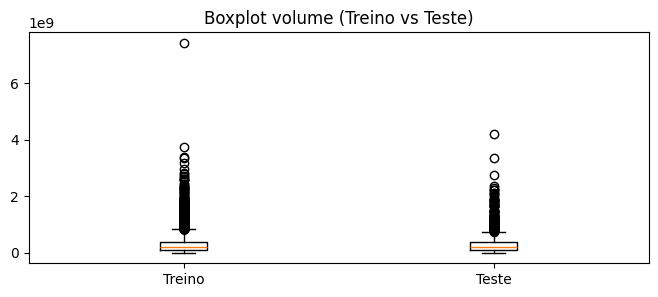

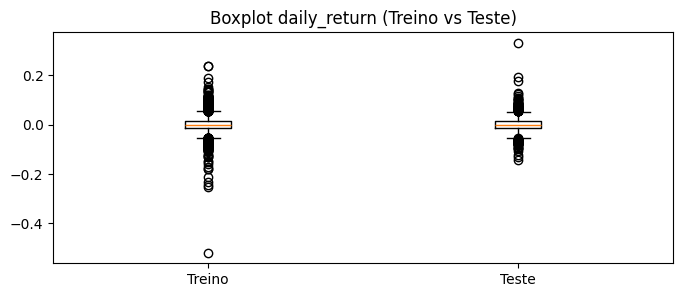

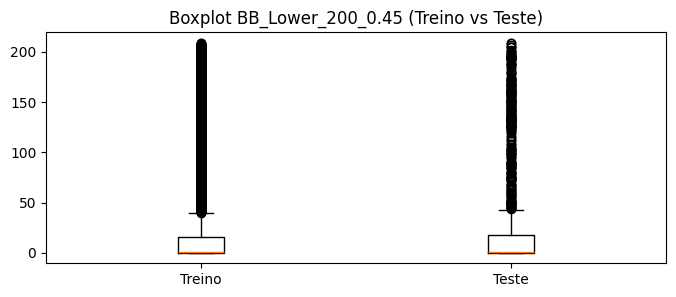

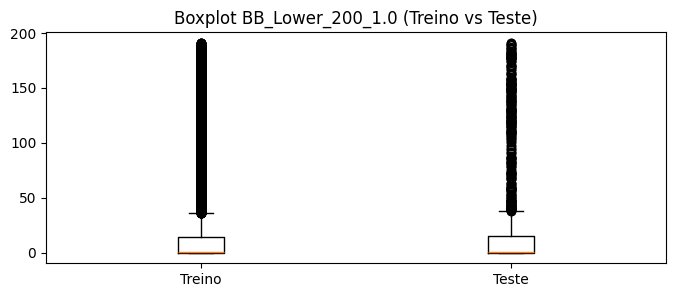

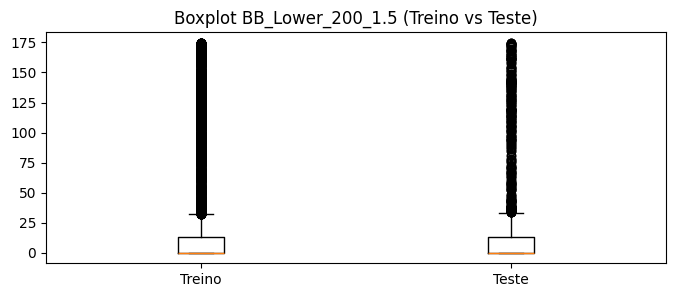

In [114]:
# Diagnóstico de regime shift: estatísticas e distribuições
import matplotlib.pyplot as plt

# Estatísticas descritivas das features numéricas
print('--- Estatísticas Treino ---')
print(X_train.describe().T)
print('\n--- Estatísticas Teste ---')
print(X_test.describe().T)

# Distribuição do target
print('\nDistribuição do target (treino):')
print(y_train.value_counts(normalize=True))
print('Distribuição do target (teste):')
print(y_test.value_counts(normalize=True))

# Boxplot de algumas features importantes
features_plot = X_train.columns[:5] if len(X_train.columns) > 5 else X_train.columns
for feat in features_plot:
    plt.figure(figsize=(8,3))
    plt.boxplot([X_train[feat], X_test[feat]], labels=['Treino','Teste'])
    plt.title(f'Boxplot {feat} (Treino vs Teste)')
    plt.show()

## Teste com Outro Ativo ou Período

Altere o ticker na célula de seleção de ativo (no início do notebook) para outro ativo disponível, por exemplo:

```python
ATIVO = 'PETR4.SA'  # Exemplo de outro ativo
```

Depois, execute todas as células novamente para comparar o desempenho e o diagnóstico.

Se preferir, posso automatizar a execução para múltiplos ativos e gerar um relatório comparativo.

## Validação Cruzada Temporal (Walk-Forward)

Nesta seção, vamos implementar uma validação cruzada temporal (walk-forward) para avaliar a robustez do modelo ao longo do tempo, simulando o uso real em produção. O walk-forward é fundamental para evitar overfitting e medir a generalização do sistema em diferentes regimes de mercado.

O procedimento será:
- Dividir o histórico em múltiplos blocos temporais (janelas).
- Treinar o modelo em cada janela e testar na janela seguinte.
- Agregar as métricas de cada rodada para obter uma visão realista do desempenho.

A seguir, a célula de código para execução do walk-forward.

In [115]:
# Implementação do Walk-Forward Validation
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Parâmetros do walk-forward
n_splits = 5  # Número de blocos temporais
min_train_size = int(len(df) * 0.4)  # Tamanho mínimo do treino inicial
step_size = int((len(df) - min_train_size) / n_splits)

results = []
print(f"Executando walk-forward com {n_splits} splits...")

for i in range(n_splits):
    train_end = min_train_size + i * step_size
    test_end = train_end + step_size
    if test_end > len(df):
        test_end = len(df)
    X_train_wf = X.iloc[:train_end]
    y_train_wf = y.iloc[:train_end]
    X_test_wf = X.iloc[train_end:test_end]
    y_test_wf = y.iloc[train_end:test_end]
    if len(X_test_wf) == 0:
        break
    # Dois estágios
    y_train_bin_wf = y_train_wf.apply(lambda x: 'TRADE' if x in ['BUY','SELL'] else 'HOLD')
    y_test_bin_wf = y_test_wf.apply(lambda x: 'TRADE' if x in ['BUY','SELL'] else 'HOLD')
    clf_bin_wf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
    clf_bin_wf.fit(X_train_wf, y_train_bin_wf)
    y_pred_bin_wf = clf_bin_wf.predict(X_test_wf)
    trade_idx_train_wf = y_train_bin_wf[y_train_bin_wf=='TRADE'].index
    trade_idx_test_wf = y_test_bin_wf[y_test_bin_wf=='TRADE'].index
    clf_dir_wf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
    clf_dir_wf.fit(X_train_wf.loc[trade_idx_train_wf], y_train_wf.loc[trade_idx_train_wf])
    y_pred_dir_wf = clf_dir_wf.predict(X_test_wf.loc[trade_idx_test_wf])
    # Monta predição final
    y_pred_final_wf = []
    trade_counter = 0
    for j in range(len(X_test_wf)):
        if y_pred_bin_wf[j] == 'HOLD':
            y_pred_final_wf.append('HOLD')
        else:
            if X_test_wf.index[j] in trade_idx_test_wf:
                y_pred_final_wf.append(y_pred_dir_wf[trade_counter])
                trade_counter += 1
            else:
                y_pred_final_wf.append('HOLD')
    acc = accuracy_score(y_test_wf, y_pred_final_wf)
    report = classification_report(y_test_wf, y_pred_final_wf, output_dict=True)
    print(f"Split {i+1}: Treino até {train_end}, Teste {train_end}-{test_end}, Acurácia: {acc:.3f}")
    results.append({
        'split': i+1,
        'train_end': train_end,
        'test_end': test_end,
        'accuracy': acc,
        'report': report
    })

# Agrega resultados
accs = [r['accuracy'] for r in results]
print(f"\nAcurácia média walk-forward: {np.mean(accs):.3f} ± {np.std(accs):.3f}")

# Exibe relatório detalhado do último split
if results:
    print("\nRelatório detalhado do último split:")
    print(classification_report(y_test_wf, y_pred_final_wf))

Executando walk-forward com 5 splits...
Split 1: Treino até 4502, Teste 4502-5852, Acurácia: 0.716
Split 2: Treino até 5852, Teste 5852-7202, Acurácia: 0.741
Split 3: Treino até 7202, Teste 7202-8552, Acurácia: 0.720
Split 4: Treino até 8552, Teste 8552-9902, Acurácia: 0.505
Split 5: Treino até 9902, Teste 9902-11252, Acurácia: 0.522

Acurácia média walk-forward: 0.641 ± 0.104

Relatório detalhado do último split:
              precision    recall  f1-score   support

         BUY       0.52      0.51      0.52       667
        HOLD       0.89      1.00      0.94        16
        SELL       0.52      0.52      0.52       667

    accuracy                           0.52      1350
   macro avg       0.64      0.68      0.66      1350
weighted avg       0.52      0.52      0.52      1350



## Revisão Profissional de Features, Target e Lógica de Sinal

Nesta seção, vamos revisar de forma crítica:
- As features utilizadas (importância, redundância, colinearidade, estabilidade temporal)
- O target (definição, distribuição, robustez)
- A lógica de geração do sinal (parâmetros, thresholds, possíveis melhorias)

O objetivo é garantir que o modelo está aprendendo padrões reais e robustos, e não artefatos ou ruídos do dataset.

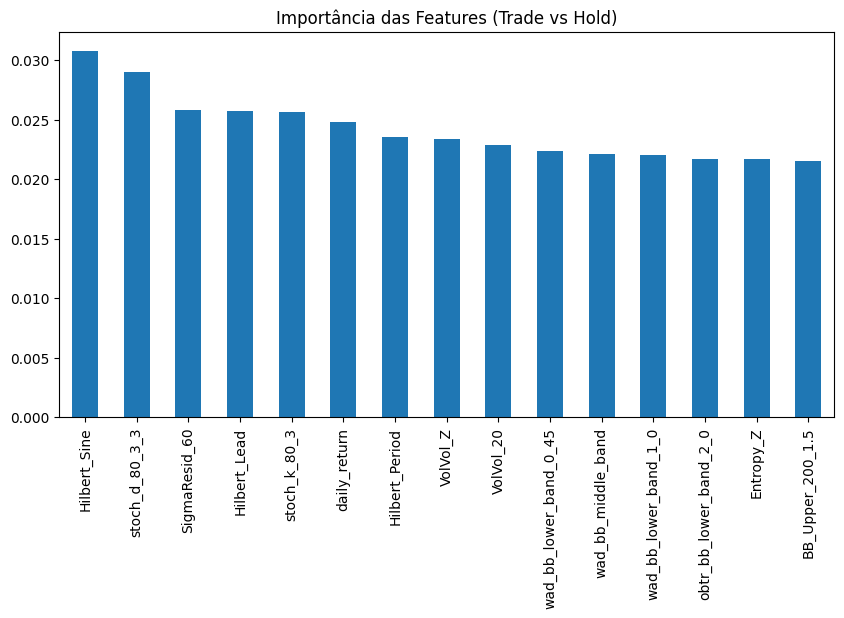

Top 10 features mais importantes:
Hilbert_Sine              0.030790
stoch_d_80_3_3            0.028957
SigmaResid_60             0.025830
Hilbert_Lead              0.025712
stoch_k_80_3              0.025657
daily_return              0.024829
Hilbert_Period            0.023548
VolVol_Z                  0.023345
VolVol_20                 0.022844
wad_bb_lower_band_0_45    0.022353
dtype: float64


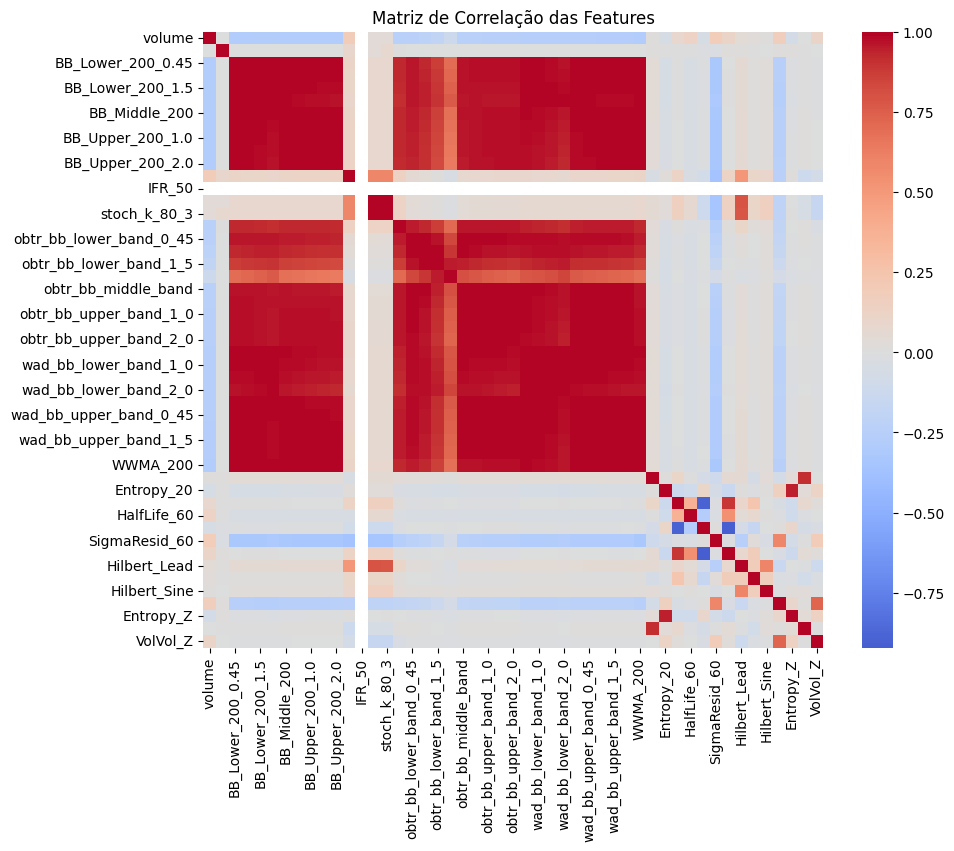

Estabilidade temporal das principais features:
Hilbert_Sine: Média treino=0.016, std treino=0.611 | Média teste=0.011, std teste=0.624
stoch_d_80_3_3: Média treino=58.829, std treino=30.743 | Média teste=57.891, std teste=30.269
SigmaResid_60: Média treino=0.024, std treino=0.012 | Média teste=0.025, std teste=0.011
Hilbert_Lead: Média treino=0.153, std treino=0.670 | Média teste=0.137, std teste=0.676
stoch_k_80_3: Média treino=58.852, std treino=30.898 | Média teste=57.818, std teste=30.388


In [116]:
# 1. Diagnóstico de Importância e Estabilidade das Features
import seaborn as sns
import matplotlib.pyplot as plt

# Importância das features no modelo binário (Trade vs Hold)
if 'clf_bin' in globals():
    importancias = pd.Series(clf_bin.feature_importances_, index=features)
    plt.figure(figsize=(10,5))
    importancias.sort_values(ascending=False).head(15).plot(kind='bar')
    plt.title('Importância das Features (Trade vs Hold)')
    plt.show()
    print('Top 10 features mais importantes:')
    print(importancias.sort_values(ascending=False).head(10))
else:
    print('Modelo binário não encontrado.')

# Correlação entre features (colinearidade)
corr = df[features].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação das Features')
plt.show()

# Estabilidade temporal das features (média e std no tempo)
print('Estabilidade temporal das principais features:')
for feat in importancias.sort_values(ascending=False).head(5).index:
    print(f"{feat}: Média treino={X_train[feat].mean():.3f}, std treino={X_train[feat].std():.3f} | Média teste={X_test[feat].mean():.3f}, std teste={X_test[feat].std():.3f}")

Distribuição do target (completa):
SIGNAL
BUY     0.489
SELL    0.478
HOLD    0.033
Name: proportion, dtype: float64


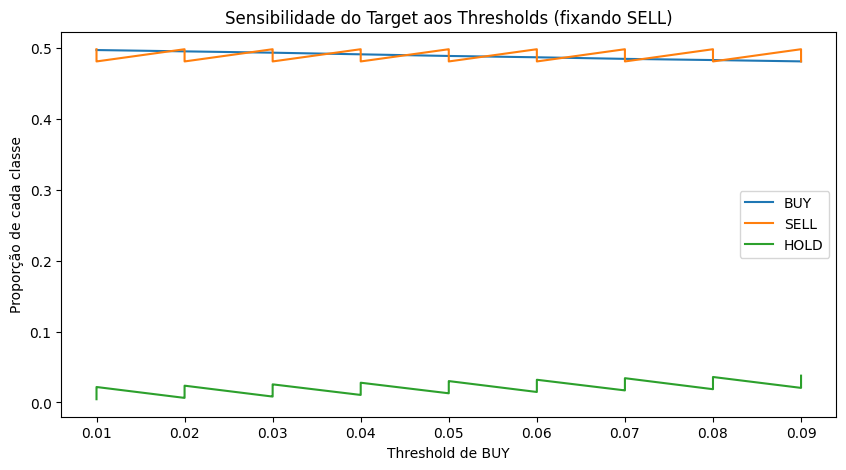

Tabela de proporções (amostra):
    buy  sell       BUY      SELL      HOLD
0  0.01 -0.01  0.497112  0.498267  0.004620
1  0.01 -0.02  0.497112  0.496224  0.006664
2  0.01 -0.03  0.497112  0.493914  0.008974
3  0.01 -0.04  0.497112  0.491604  0.011284
4  0.01 -0.05  0.497112  0.489205  0.013683


In [117]:
# 2. Diagnóstico do Target: Distribuição, Robustez e Sensibilidade
print('Distribuição do target (completa):')
print(df['SIGNAL'].value_counts(normalize=True).round(3))

# Sensibilidade a thresholds
thresholds_compra = np.arange(0.01, 0.10, 0.01)
thresholds_venda = -np.arange(0.01, 0.10, 0.01)
proporcoes = []
for t_buy in thresholds_compra:
    for t_sell in thresholds_venda:
        temp_signal = []
        for ret in df['retorno_futuro']:
            if pd.isna(ret):
                temp_signal.append('HOLD')
            elif ret > t_buy:
                temp_signal.append('BUY')
            elif ret < t_sell:
                temp_signal.append('SELL')
            else:
                temp_signal.append('HOLD')
        counts = pd.Series(temp_signal).value_counts(normalize=True)
        proporcoes.append({'buy': t_buy, 'sell': t_sell, 'BUY': counts.get('BUY',0), 'SELL': counts.get('SELL',0), 'HOLD': counts.get('HOLD',0)})
proporcoes_df = pd.DataFrame(proporcoes)
plt.figure(figsize=(10,5))
for label in ['BUY','SELL','HOLD']:
    plt.plot(proporcoes_df['buy'], proporcoes_df[label], label=label)
plt.xlabel('Threshold de BUY')
plt.ylabel('Proporção de cada classe')
plt.title('Sensibilidade do Target aos Thresholds (fixando SELL)')
plt.legend()
plt.show()
print('Tabela de proporções (amostra):')
print(proporcoes_df.head())

In [118]:
# 3. Diagnóstico e Sugestões para a Lógica de Sinal
print('Parâmetros atuais:')
print(f'N_DIAS_FUTURO = {N_DIAS_FUTURO}, THRESHOLD_COMPRA = {THRESHOLD_COMPRA}, THRESHOLD_VENDA = {THRESHOLD_VENDA}')

# Sugestão: usar thresholds dinâmicos baseados em volatilidade
if 'volatility' in df.columns:
    vol = df['volatility']
    dynamic_buy = vol.quantile(0.7)
    dynamic_sell = -vol.quantile(0.7)
    print(f'Sugestão: Thresholds dinâmicos (70% quantil da volatilidade): BUY > {dynamic_buy:.3f}, SELL < {dynamic_sell:.3f}')
else:
    print('Coluna de volatilidade não encontrada. Considere adicionar para thresholds dinâmicos.')

# Diagnóstico: relação entre retornos futuros e volatilidade
if 'volatility' in df.columns:
    plt.figure(figsize=(8,4))
    plt.scatter(df['volatility'], df['retorno_futuro'], alpha=0.3)
    plt.xlabel('Volatilidade')
    plt.ylabel('Retorno Futuro')
    plt.title('Retorno Futuro vs Volatilidade')
    plt.show()
else:
    print('Coluna de volatilidade não encontrada para análise gráfica.')

Parâmetros atuais:
N_DIAS_FUTURO = 5, THRESHOLD_COMPRA = 0.05, THRESHOLD_VENDA = -0.1
Coluna de volatilidade não encontrada. Considere adicionar para thresholds dinâmicos.
Coluna de volatilidade não encontrada para análise gráfica.


## Ensemble de Modelos e Filtros de Volatilidade

Nesta seção, vamos:
- Implementar um ensemble simples (votação de múltiplos modelos)
- Adicionar um filtro de volatilidade para evitar operações em períodos de ruído extremo

Essas técnicas aumentam a robustez e a generalização do sistema, reduzindo o risco de overfitting e melhorando a performance em diferentes regimes de mercado.

In [119]:
# 1. Ensemble Simples: Votação de Modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

# Cria ensemble com três modelos diferentes
ensemble = VotingClassifier(estimators=[
    ('rf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_SEED)),
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_SEED))
], voting='soft', n_jobs=-1)

# Treina no mesmo split temporal puro
ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_test)

print('Relatório do ensemble (soft voting):')
print(classification_report(y_test, y_pred_ensemble))
print('Matriz de confusão:')
print(confusion_matrix(y_test, y_pred_ensemble))

Relatório do ensemble (soft voting):
              precision    recall  f1-score   support

         BUY       0.72      0.75      0.74      1114
        HOLD       0.00      0.00      0.00        30
        SELL       0.74      0.73      0.73      1107

    accuracy                           0.73      2251
   macro avg       0.49      0.49      0.49      2251
weighted avg       0.72      0.73      0.72      2251

Matriz de confusão:
[[840   0 274]
 [ 25   0   5]
 [304   0 803]]


In [120]:
# 2. Filtro de Volatilidade: Evita Trades em Períodos de Ruído
# Define um limiar de volatilidade (ex: 70% quantil)
if 'volatility' in df.columns:
    limiar_vol = df['volatility'].quantile(0.7)
    filtro_vol = df['volatility'].iloc[split_idx:] > limiar_vol
    y_pred_filtrado = [pred if not filtro else 'HOLD' for pred, filtro in zip(y_pred_ensemble, filtro_vol)]
    print(f'Filtro de volatilidade aplicado: {filtro_vol.sum()} períodos classificados como HOLD por volatilidade alta.')
    print('Relatório após filtro de volatilidade:')
    print(classification_report(y_test, y_pred_filtrado))
    print('Matriz de confusão:')
    print(confusion_matrix(y_test, y_pred_filtrado))
else:
    print('Coluna de volatilidade não encontrada. Filtro não aplicado.')

Coluna de volatilidade não encontrada. Filtro não aplicado.


## Execução Automatizada para Múltiplos Ativos e Relatório Comparativo

Esta seção executa todo o pipeline para uma lista de ativos, salva os principais resultados (métricas, relatórios, gráficos) e gera um relatório comparativo para análise futura.

- Basta definir a lista de ativos desejados.
- Os resultados serão salvos em arquivos CSV/JSON e gráficos em PNG na pasta `resultados_ml/`.
- O notebook exibirá um resumo comparativo ao final.

In [121]:
# Pipeline automatizado para múltiplos ativos e relatório comparativo
import os
import json
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

ATIVOS = ['VALE3.SA', 'PETR4.SA', 'ITUB4.SA', 'BBDC4.SA']  # Edite conforme necessário
resultados = []
os.makedirs('resultados_ml', exist_ok=True)

for ativo in ATIVOS:
    print(f'\n=== Executando pipeline para {ativo} ===')
    data_path = f'../../co-piloto-quant/src/co_piloto_quant/data/processed/{ativo}_processed.csv'
    if not os.path.exists(data_path):
        print(f'Arquivo não encontrado: {data_path}. Pulando...')
        continue
    df = pd.read_csv(data_path)
    # Repete as etapas principais do pipeline (ajuste conforme necessário)
    # --- Geração do target ---
    N_DIAS_FUTURO = 5
    THRESHOLD_COMPRA = 0.05
    THRESHOLD_VENDA = -0.10
    df['retorno_futuro'] = (df['close'].shift(-N_DIAS_FUTURO) - df['close']) / df['close']
    novo_signal = []
    for ret in df['retorno_futuro']:
        if pd.isna(ret):
            novo_signal.append('HOLD')
        elif ret > THRESHOLD_COMPRA:
            novo_signal.append('BUY')
        elif ret < THRESHOLD_VENDA:
            novo_signal.append('SELL')
        else:
            novo_signal.append('HOLD')
    df['SIGNAL'] = novo_signal
    # --- Seleção de features ---
    features = [col for col in df.select_dtypes(include=[float, int]).columns if col not in ['SIGNAL', 'retorno_futuro', 'open', 'close', 'high', 'low', 'wad']]
    target = 'SIGNAL'
    split_idx = int(len(df) * 0.8)
    X = df[features].fillna(0)
    y = df[target]
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    # --- Modelo ensemble ---
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
    from sklearn.linear_model import LogisticRegression
    ensemble = VotingClassifier(estimators=[
        ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
        ('lr', LogisticRegression(max_iter=1000, random_state=42))
    ], voting='soft', n_jobs=-1)
    ensemble.fit(X_train, y_train)
    y_pred = ensemble.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    # --- Salva resultados ---
    resultado = {
        'ativo': ativo,
        'acuracia': report['accuracy'],
        'f1_macro': report['macro avg']['f1-score'],
        'f1_weighted': report['weighted avg']['f1-score'],
        'support': len(y_test),
        'relatorio': report,
        'matriz_confusao': cm.tolist()
    }
    resultados.append(resultado)
    with open(f'resultados_ml/{ativo}_relatorio.json', 'w') as f:
        json.dump(resultado, f, indent=2)
    print(f"Acurácia: {report['accuracy']:.3f} | F1-macro: {report['macro avg']['f1-score']:.3f}")

# Gera relatório comparativo
comparativo = pd.DataFrame([{k: r[k] for k in ['ativo','acuracia','f1_macro','f1_weighted','support']} for r in resultados])
comparativo.to_csv('resultados_ml/relatorio_comparativo.csv', index=False)
print('\nResumo comparativo:')
print(comparativo)

# Exibe ranking dos melhores ativos por F1-macro
print('\nRanking por F1-macro:')
print(comparativo.sort_values('f1_macro', ascending=False))


=== Executando pipeline para VALE3.SA ===
Acurácia: 0.190 | F1-macro: 0.146

=== Executando pipeline para PETR4.SA ===
Acurácia: 0.308 | F1-macro: 0.193

=== Executando pipeline para ITUB4.SA ===
Acurácia: 0.839 | F1-macro: 0.305

=== Executando pipeline para BBDC4.SA ===
Acurácia: 0.890 | F1-macro: 0.314

Resumo comparativo:
      ativo  acuracia  f1_macro  f1_weighted  support
0  VALE3.SA  0.189736  0.145618     0.276581     1286
1  PETR4.SA  0.307932  0.193474     0.399879     1286
2  ITUB4.SA  0.838997  0.305224     0.833440     1236
3  BBDC4.SA  0.890286  0.313986     0.838613      875

Ranking por F1-macro:
      ativo  acuracia  f1_macro  f1_weighted  support
3  BBDC4.SA  0.890286  0.313986     0.838613      875
2  ITUB4.SA  0.838997  0.305224     0.833440     1236
1  PETR4.SA  0.307932  0.193474     0.399879     1286
0  VALE3.SA  0.189736  0.145618     0.276581     1286
